Updated model to modify for normalization N and baseline B.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [339]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.rg1_refactor import load_default_chrom_configs

config, _ = load_default_chrom_configs()

real_deconv1 = RealDataReplicationDeconvolution(config, replicate=1)

Initializing N using config H.
Initializing B using timepoint 0


###### 

In [350]:
real_deconv1.config.params_dic['mu0'] = -20.89
real_deconv1.config.params_dic['delta'] = 0
real_deconv1.config.params_dic['sigma0'] = 4.84
real_deconv1.config.params_dic['lambda'] = 65
real_deconv1.config.params_dic['gamma1'] = 0.0
real_deconv1.config.params_dic['halted'] = 0.2

In [351]:
real_deconv1.config.update_timepoints()
real_deconv1.config.calculate_H()
real_deconv1.config.params_dic

{'mu0': -20.89,
 'delta': 0,
 'sigma0': 4.84,
 'sigmav': 0.1424,
 'lambda': 65,
 'gamma1': 0.0,
 'gamma2': 0.2547,
 'halted': 0.2,
 'alpha': 22,
 '65': 4.84}

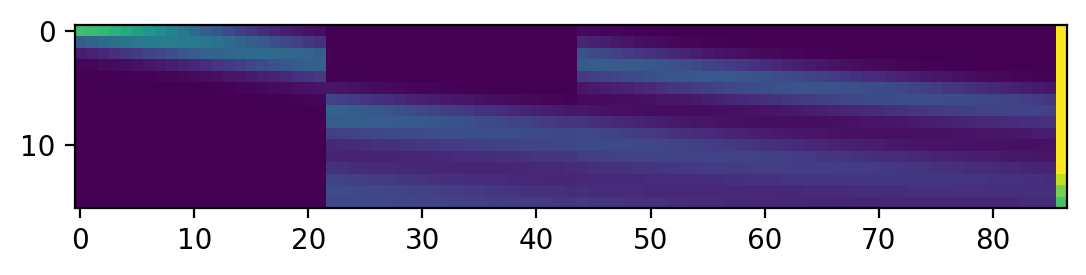

In [352]:
plt.imshow(real_deconv1.H, vmax=0.1)

In [353]:
real_deconv1.iterative_deconvolution_updates(5)

Iteration 0
0/368 - 00:00:00.002
100/368 - 00:00:00.080
200/368 - 00:00:00.158
300/368 - 00:00:00.239
Iteration completed 00:00:00.305, rn=0.006283419901301833
Iteration 1
0/368 - 00:00:00.306
100/368 - 00:00:00.389
200/368 - 00:00:00.469
300/368 - 00:00:00.549
Iteration completed 00:00:00.615, rn=0.00442703733302984
Iteration 2
0/368 - 00:00:00.617
100/368 - 00:00:00.695
200/368 - 00:00:00.778
300/368 - 00:00:00.856
Iteration completed 00:00:01.077, rn=0.0041131527656155424
Iteration 3
0/368 - 00:00:01.079
100/368 - 00:00:01.160
200/368 - 00:00:01.241
300/368 - 00:00:01.323
Iteration completed 00:00:01.398, rn=0.003953469425160774
Iteration 4
0/368 - 00:00:01.400
100/368 - 00:00:01.479
200/368 - 00:00:01.560
300/368 - 00:00:01.642
Iteration completed 00:00:01.717, rn=0.0038850669122214667


In [354]:
# First run to get an initial estimation of F

In [355]:
from src.optimize_H import ParameterOptimizer

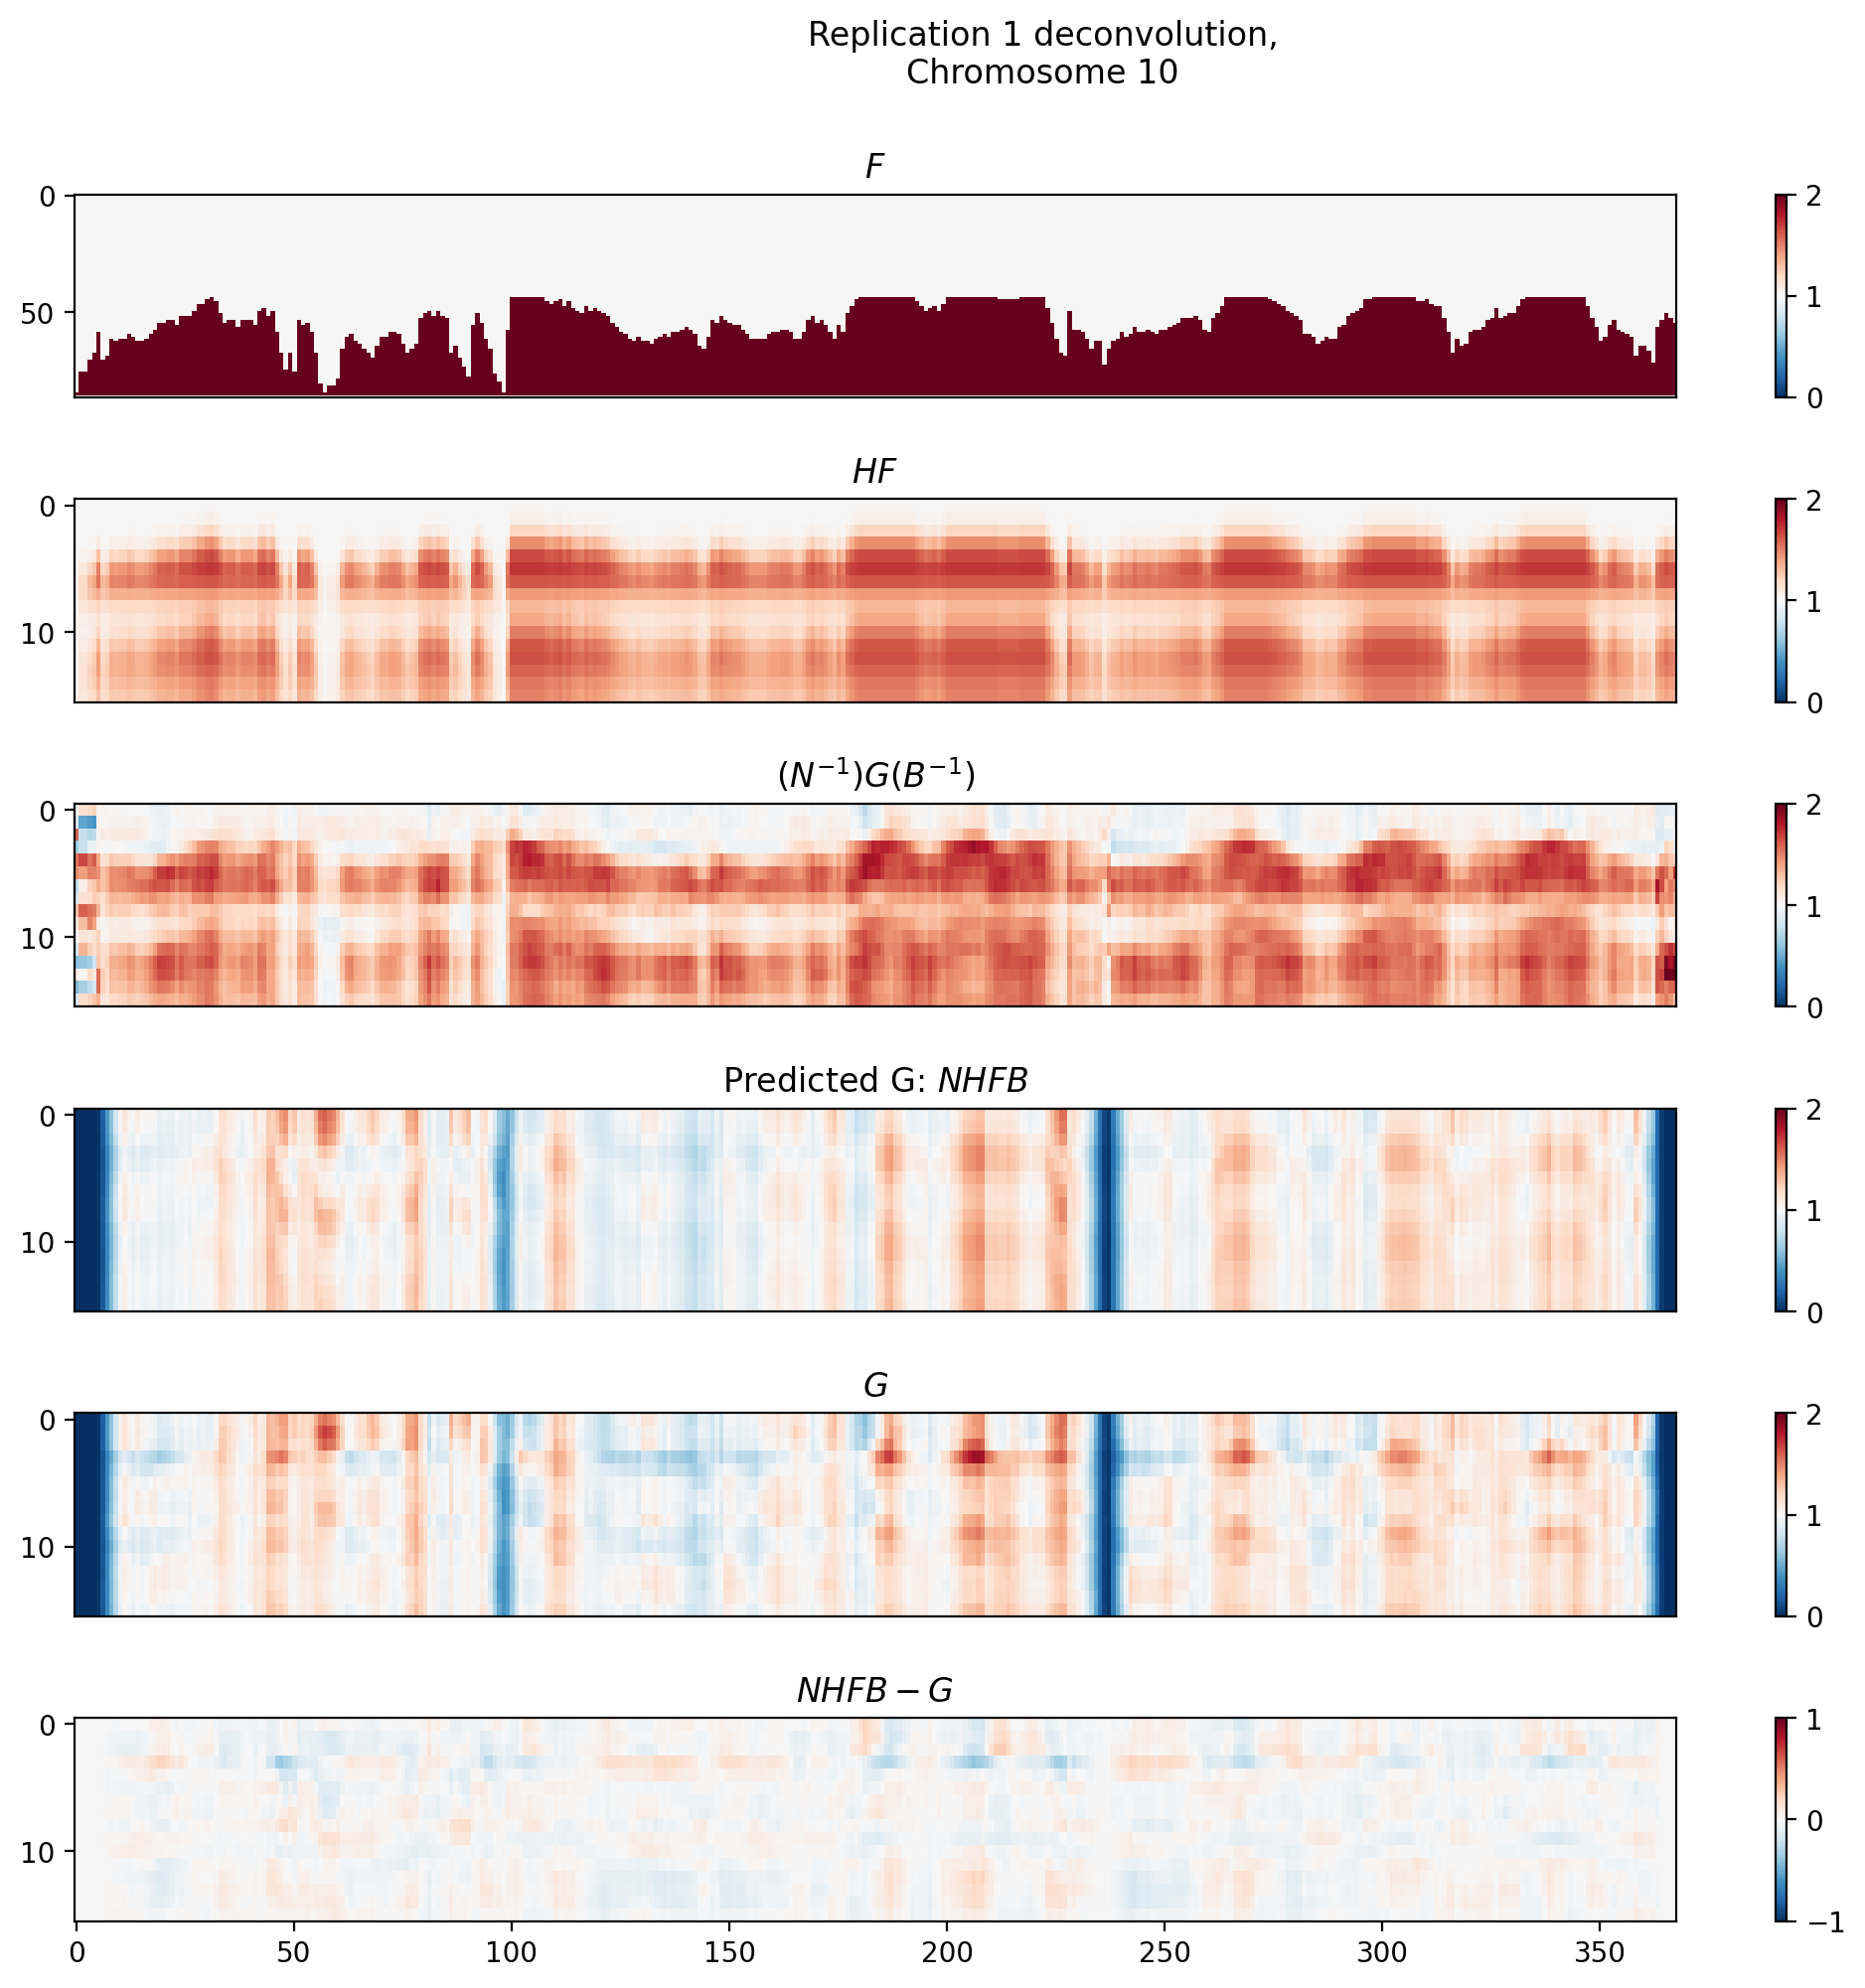

In [356]:
real_deconv1.plot_heatmaps()

In [382]:
timepoints = config.timepoints
initial_values = {
    'mu0': -20,
   'sigma0': 4,
   'delta': 8,
    'lambda': 68.19,
#     'gamma1': 0.24,
    'halted': 0.24,
}

init_params_df = pd.DataFrame(initial_values, index=['value']).T


In [383]:
bounds_dic = {
    'mu0': (-30, -10),
    'lambda': (60, 80),
    'delta': (1, 14),
    'sigma0': (1, 8),
    'halted': (0.24, 0.24),
}

bounds_params_df = pd.DataFrame(bounds_dic, index=['min', 'max']).T
params_df = init_params_df.join(bounds_params_df)
params_df


,value,min,max
mu0,-20.00,-30.00,-10.00
sigma0,4.00,1.00,8.00
delta,8.00,1.00,14.00
lambda,68.19,60.00,80.00
halted,0.24,0.24,0.24


In [384]:
start, end = 0, 368

abbreviated_G = G[:, start:end]
abbreviated_F = F[:, start:end]
abbreviated_B = B[:, start:end][start:end, :]

In [385]:
from src.timer import Timer
from src.single_G1_config import calcH

timer = Timer()

num_epochs = 10
num_iterations_N_B = 5

real_deconv1.initial_B = abbreviated_B
real_deconv1.G = abbreviated_G
real_deconv1.F = abbreviated_F

update_params_df = pd.DataFrame()

optimizer = ParameterOptimizer(
    init_params_df=params_df,
    config=config,
    N=N,
    F=abbreviated_F,
    B=abbreviated_B,
    G=abbreviated_G
)

real_deconv1.setup_deconvolution(real_deconv1.config)
N = real_deconv1.initial_N
B = real_deconv1.initial_B

for epoch in range(num_epochs):
    print("Epoch: ", epoch)
    
    optimizer.optimize(maxiter=1000, verbose=True)

    real_deconv1.config.H = optimizer.current_H
        
    real_deconv1.iterative_deconvolution_updates(
        total_iterations=num_iterations_N_B, timer=timer,
        initial_B=B, initial_N=N)
    timer.print_time()
    
    params_row = pd.DataFrame([optimizer.params_df['value']], index=[epoch])
    params_row['opt_H_loss'] = optimizer.rn
    params_row['F_rn'] = real_deconv1.rn

    update_params_df = pd.concat([update_params_df, params_row])
    
    optimizer.N = real_deconv1.N
    optimizer.B = real_deconv1.B
    optimizer.F = real_deconv1.F
    
    N = real_deconv1.N
    B = real_deconv1.B

    print(update_params_df.iloc[-1])


Initializing N using config H.
Initializing B using timepoint 0
Epoch:  0
Optimization [1]: Current loss: 0.011627178940145477
Optimization [101]: Current loss: 0.006613392981319891
Optimization [201]: Current loss: 0.006492258172825138
Optimization terminated successfully.
         Current function value: 0.006492
         Iterations: 149
         Function evaluations: 237
Iteration 0
0/368 - 00:00:54.624
100/368 - 00:00:54.703
200/368 - 00:00:54.781
300/368 - 00:00:54.860
Iteration completed 00:00:54.973, rn=0.007372677521755154
Iteration 1
0/368 - 00:00:54.974
100/368 - 00:00:55.053
200/368 - 00:00:55.132
300/368 - 00:00:55.210
Iteration completed 00:00:55.293, rn=0.004286711148134314
Iteration 2
0/368 - 00:00:55.295
100/368 - 00:00:55.372
200/368 - 00:00:55.450
300/368 - 00:00:55.529
Iteration completed 00:00:55.613, rn=0.003630833512046719
Iteration 3
0/368 - 00:00:55.614
100/368 - 00:00:55.692
200/368 - 00:00:55.770
300/368 - 00:00:55.851
Iteration completed 00:00:55.932, rn=0.00

100/368 - 00:04:00.799
200/368 - 00:04:00.878
300/368 - 00:04:00.956
Iteration completed 00:04:01.030, rn=0.0032774171812892123
Iteration 3
0/368 - 00:04:01.031
100/368 - 00:04:01.110
200/368 - 00:04:01.188
300/368 - 00:04:01.266
Iteration completed 00:04:01.336, rn=0.0032774171812892123
Iteration 4
0/368 - 00:04:01.338
100/368 - 00:04:01.416
200/368 - 00:04:01.495
300/368 - 00:04:01.573
Iteration completed 00:04:01.700, rn=0.003277417181289213
00:04:01.700
mu0          -20.272750
lambda        68.619196
delta          5.288471
sigma0         4.129555
halted         0.240000
opt_H_loss     0.003253
F_rn           0.003277
Name: 6, dtype: float64
Epoch:  7
Optimization [1]: Current loss: 0.003252751594822793
Optimization terminated successfully.
         Current function value: 0.003253
         Iterations: 36
         Function evaluations: 72
Iteration 0
0/368 - 00:04:20.417
100/368 - 00:04:20.498
200/368 - 00:04:20.578
300/368 - 00:04:20.661
Iteration completed 00:04:20.816, rn=0.0032

Text(0.5, 0.98, 'Cell cycle parameter updates, 10 epochs')

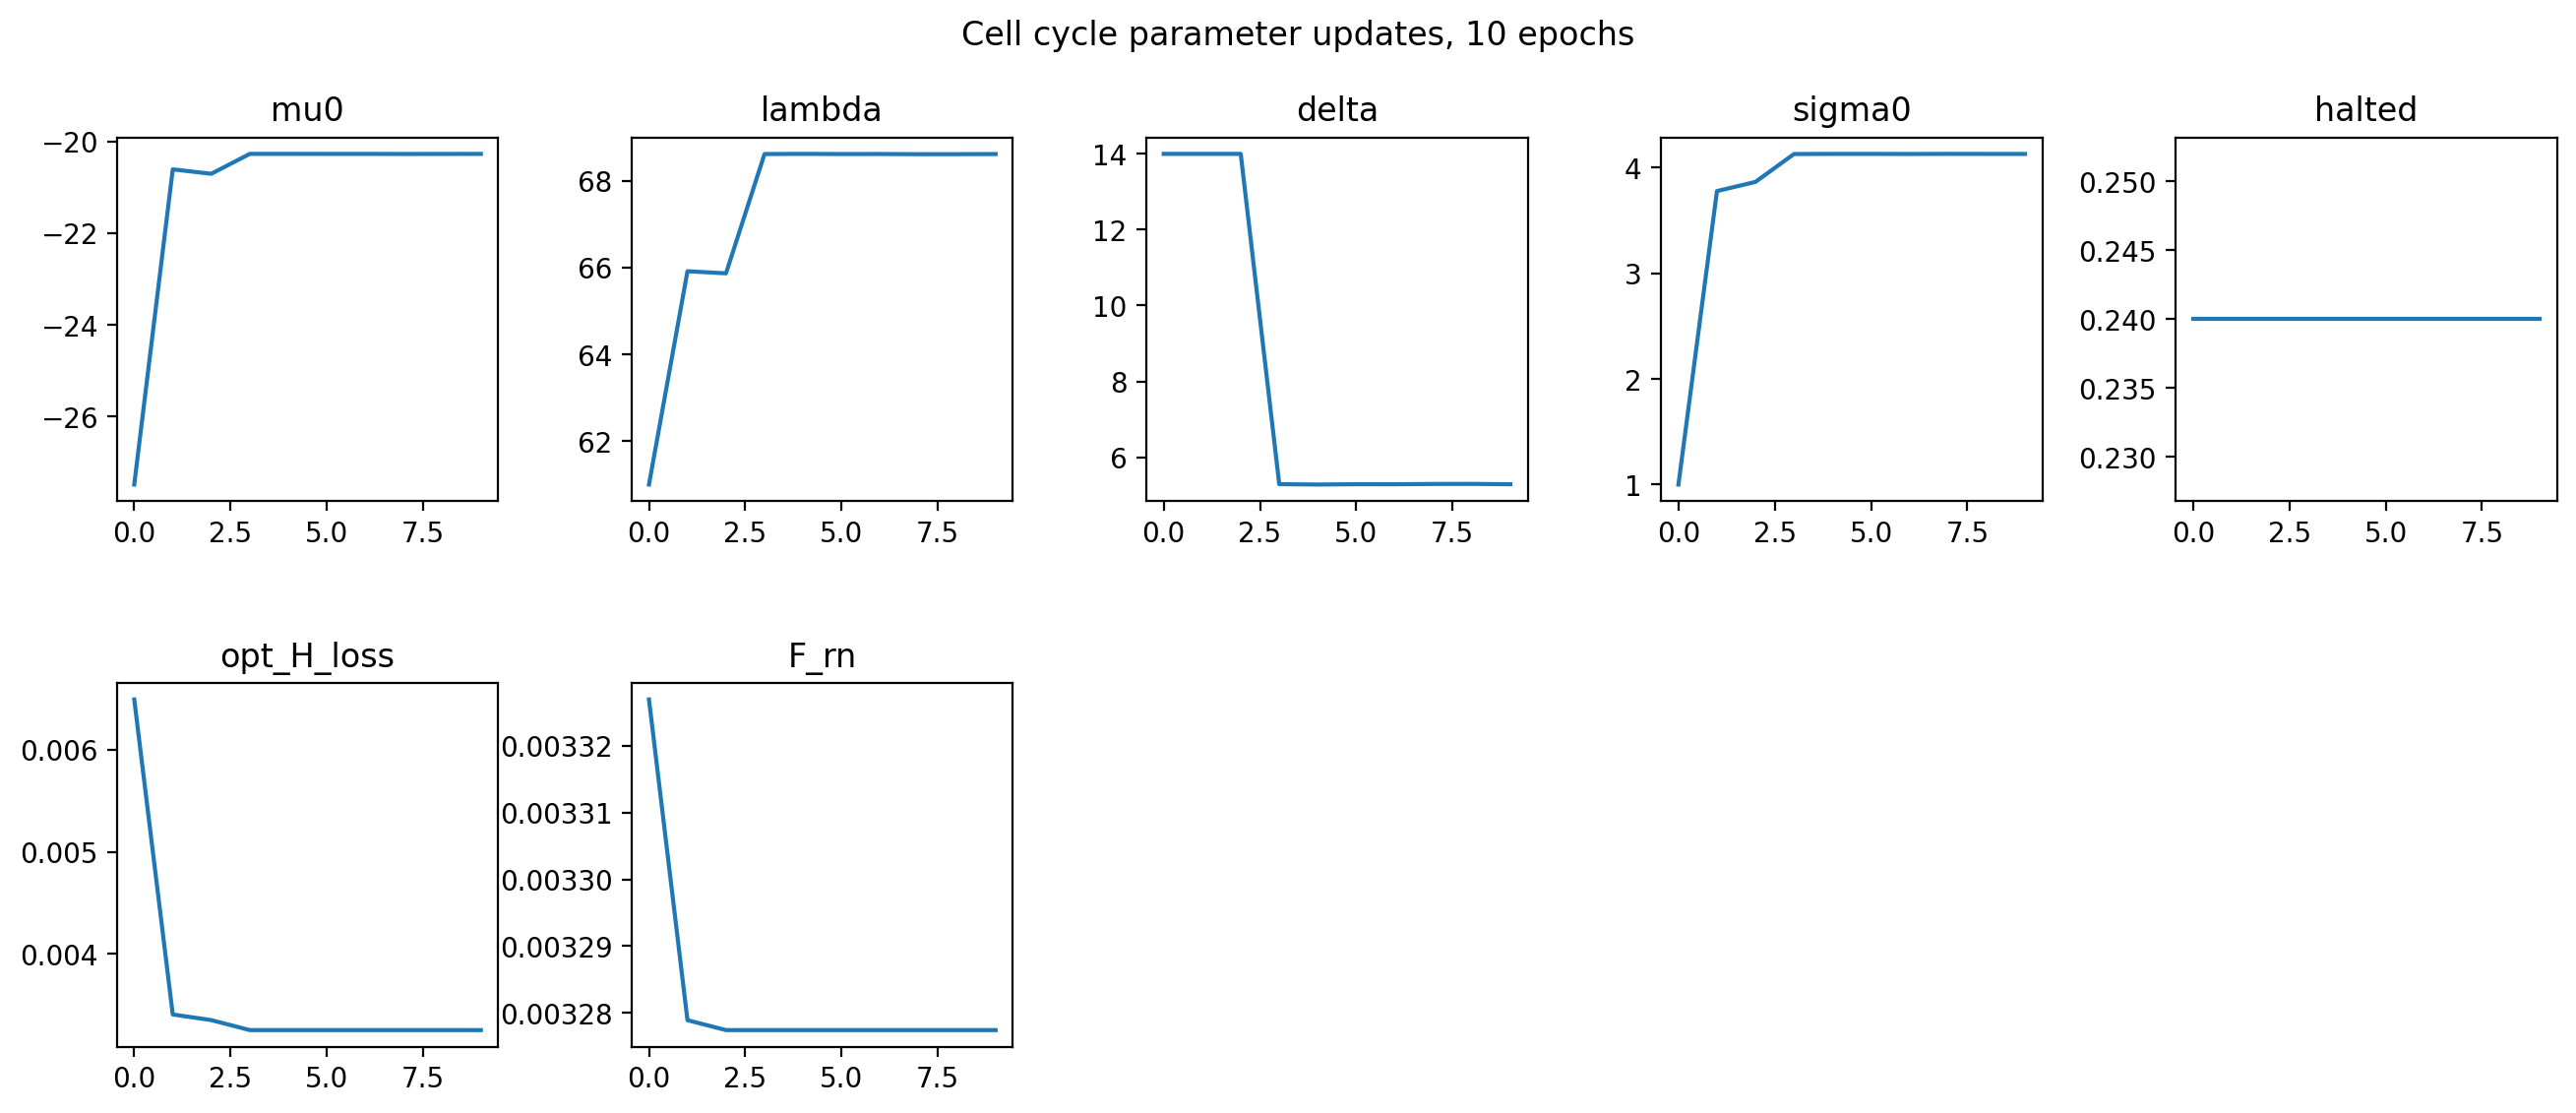

In [386]:
r, c = 2, 5

plt.figure(figsize=(16, 6))

for i, param in enumerate(update_params_df.columns):
        
    plt.subplot(r, c, i+1)
    plt.plot(update_params_df[param])
    plt.title(param)
    
plt.subplots_adjust(hspace=0.5, wspace=0.35)
plt.suptitle(f"Cell cycle parameter updates, {num_epochs} epochs")

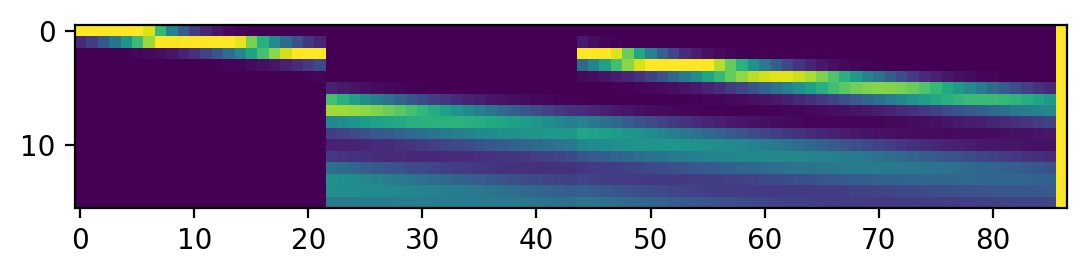

In [387]:
plt.imshow(config.H, vmax=0.05)

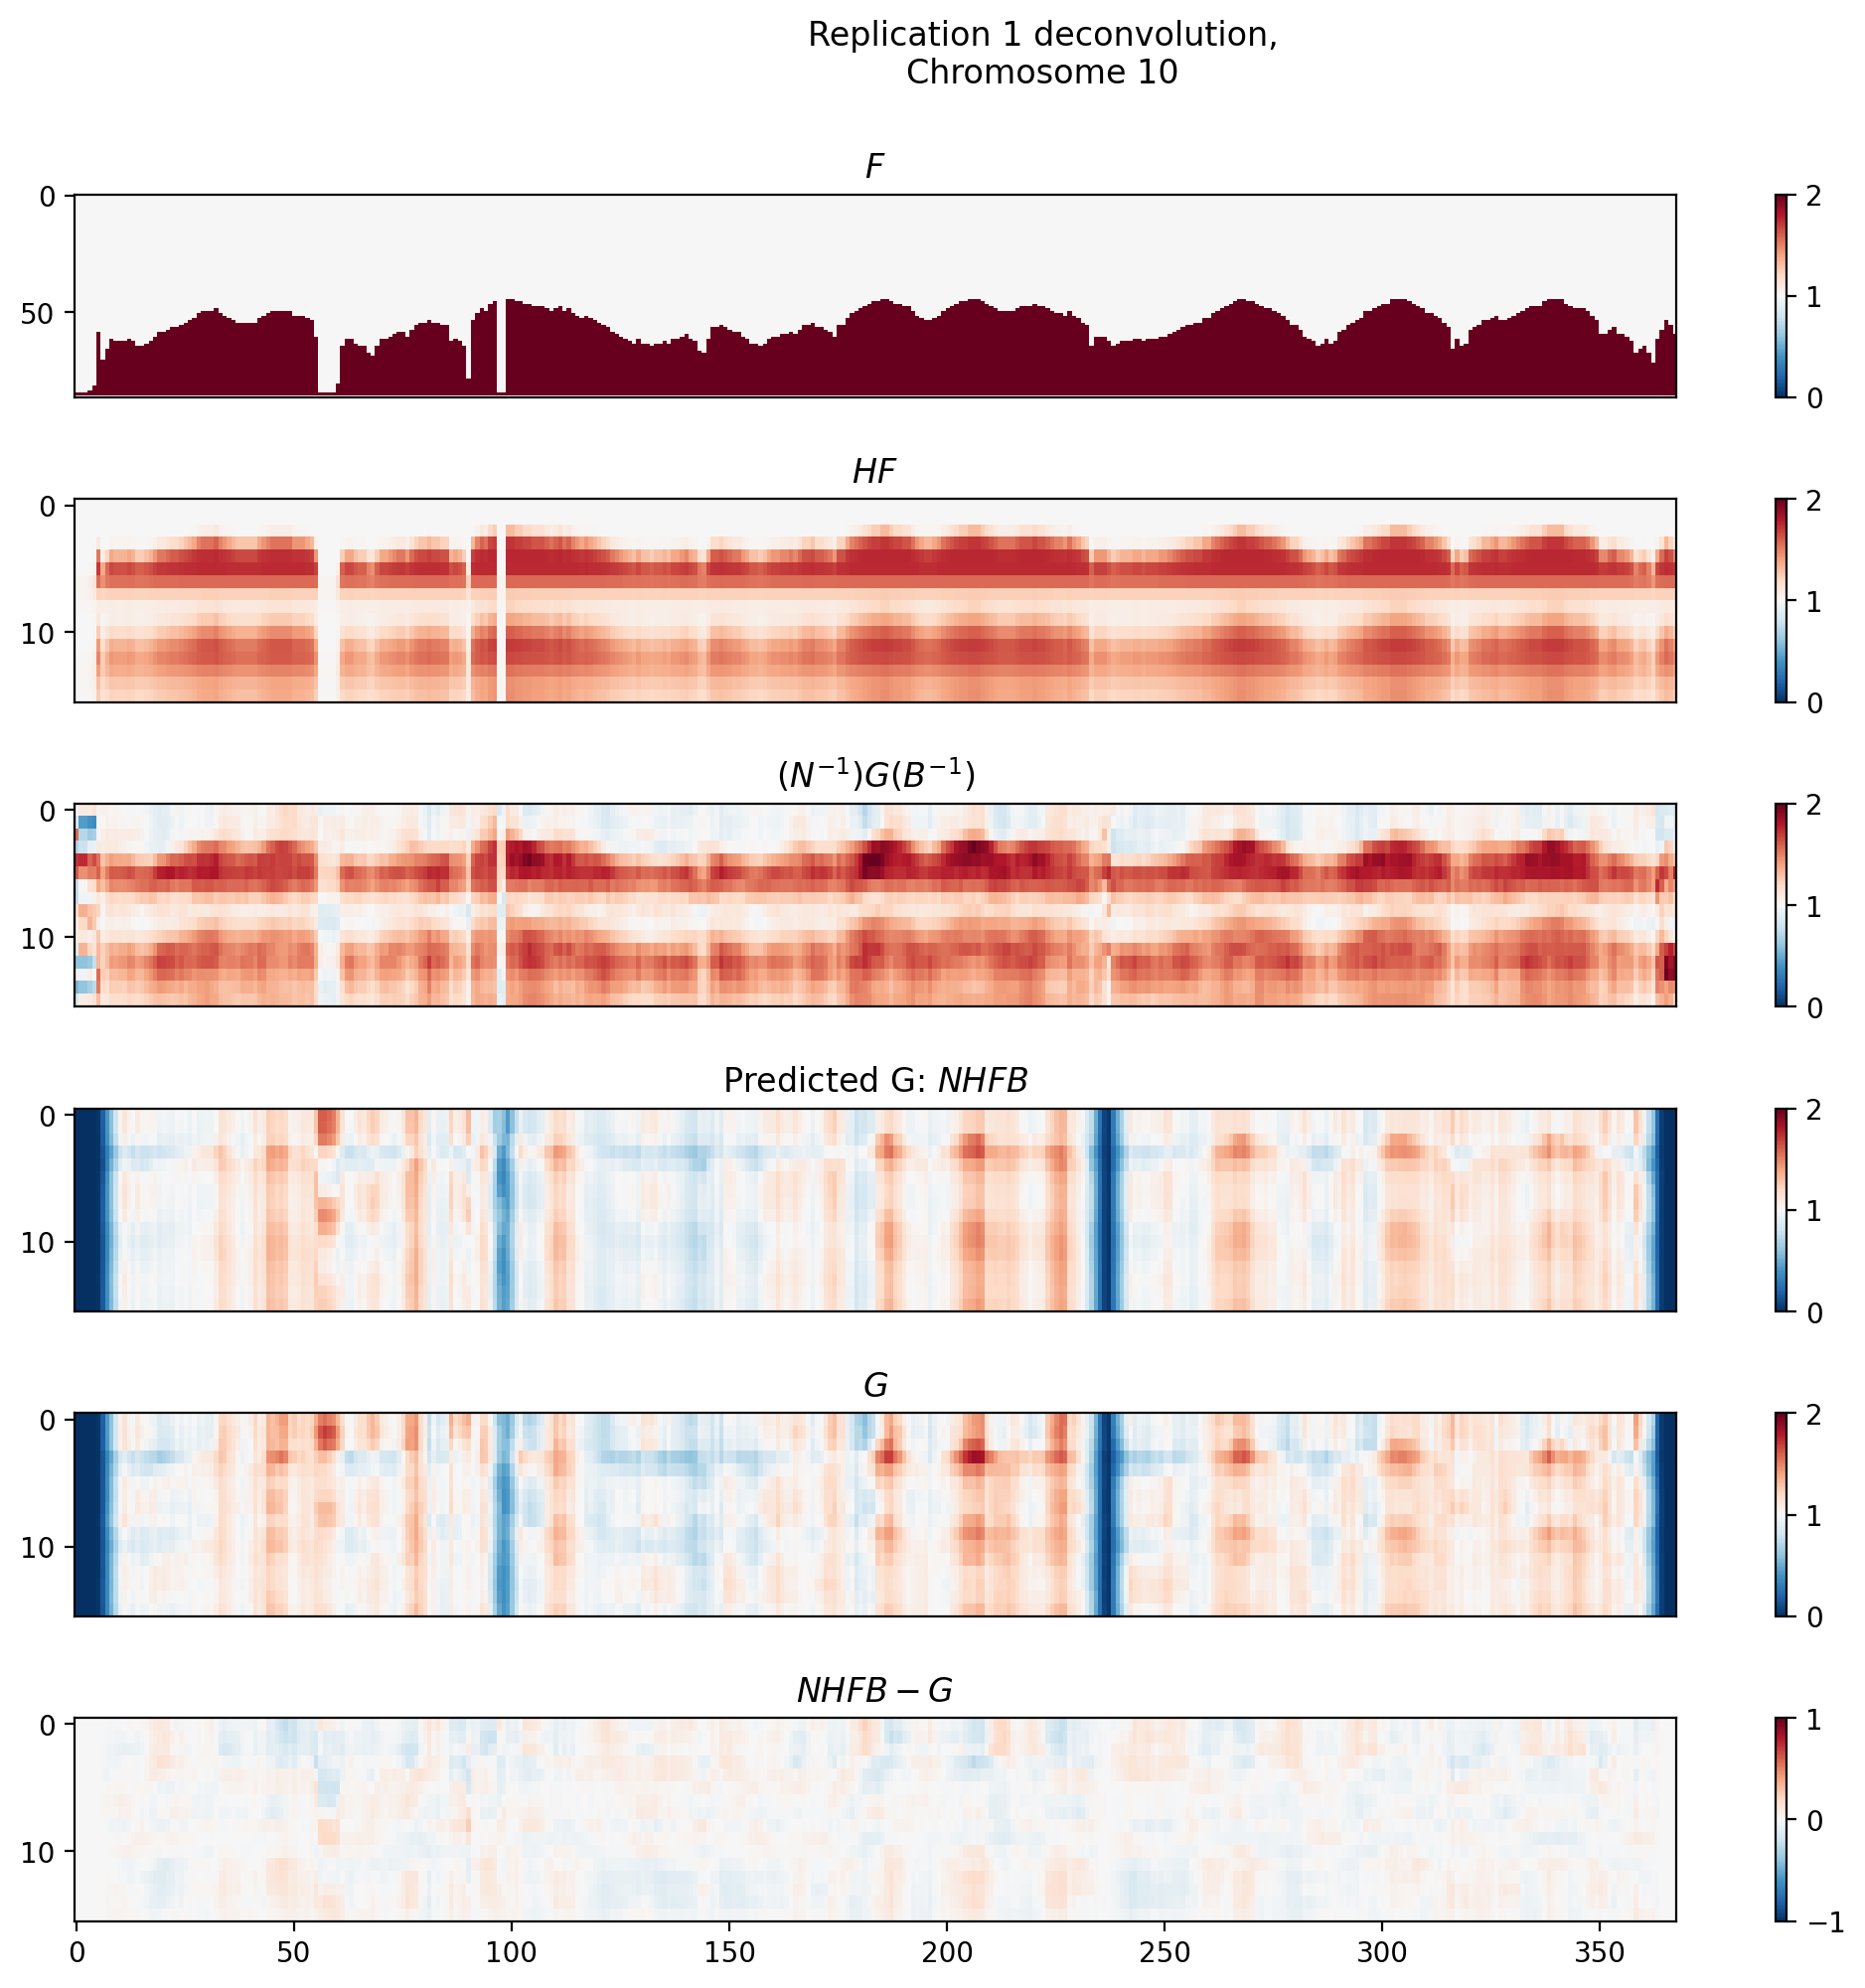

In [388]:
real_deconv1.plot_heatmaps()

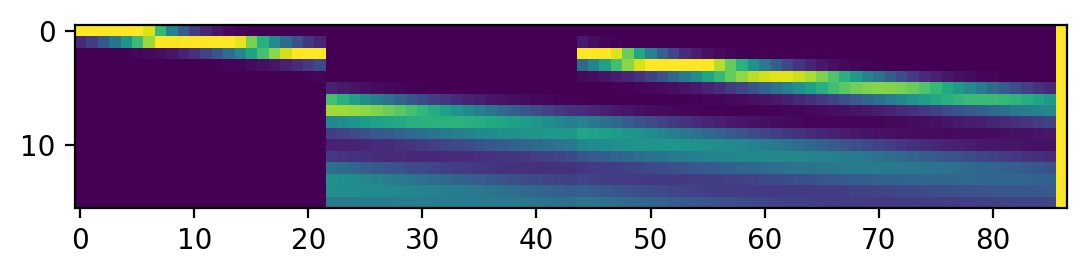

In [389]:
plt.imshow(config.H, vmax=0.05)

In [390]:
config.params_dic

{'mu0': -20.272992913991885,
 'delta': 5.28829979999932,
 'sigma0': 4.129948370963075,
 'sigmav': 0.1424,
 'lambda': 68.61825299871941,
 'gamma1': 0.0,
 'gamma2': 0.2547,
 'halted': 0.24,
 'alpha': 22,
 '65': 4.84}

In [391]:
# The learning of B is converging to some strange places..
# Let's keep track of H, N, B, and F during this learning process
# Then we can see how the fits converge, it's possible we will need to rethink how
# B is updated...
